<a href="https://colab.research.google.com/github/elhartw/ML4CHEM/blob/main/chemberta_bbbp_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. GPU check

In [1]:
import torch
print("CUDA beschikbaar:", torch.cuda.is_available())
print("GPU naam:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "geen GPU")

CUDA beschikbaar: True
GPU naam: Tesla T4


## 2. Installaties

In [2]:
!pip install -q transformers rdkit scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 31.9 MB/s eta 0:00:00


## 3. Data laden

In [3]:
import pandas as pd

URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
df = pd.read_csv(URL)

print("Aantal rijen:", len(df))
print("Kolommen:", df.columns.tolist())
df.head()

Aantal rijen: 2050
Kolommen: ['num', 'name', 'p_np', 'smiles']


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [4]:
print(df["p_np"].value_counts())
print("\nFractie positief:", df["p_np"].mean().round(3))

p_np
1    1567
0     483
Name: count, dtype: int64

Fractie positief: 0.764


## 4. SMILES opschonen: kanonieke SMILES via RDKit




In [5]:
from rdkit import Chem

def canonicalize(smiles):
    """Zet SMILES om naar kanonieke vorm. Geeft None terug bij ongeldige SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

df["smiles"] = df["smiles"].apply(canonicalize)

# Verwijder rijen met ongeldige SMILES
n_before = len(df)
df = df.dropna(subset=["smiles"]).reset_index(drop=True)
print(f"Verwijderd wegens ongeldige SMILES: {n_before - len(df)}")
print(f"Overgebleven: {len(df)} moleculen")

[11:00:59] Explicit valence for atom # 1 N, 4, is greater than permitted
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:00:59] Explicit valence for atom # 6 N, 4, is greater than permitted
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:00:59] WARNING: not removing hydrogen atom without neighbors
[11:01:00] Explicit valence for atom # 6 N, 4, is greater than permitted
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] Explicit valence for atom # 11 N, 4, is greater than pe

Verwijderd wegens ongeldige SMILES: 11
Overgebleven: 2039 moleculen


[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors


## 5. Scaffold split



In [6]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import numpy as np

def get_scaffold(smiles):
    """Geeft de Murcko scaffold van een SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles  # fallback
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def scaffold_split_stratified(df, frac_test=0.1, frac_val=0.1, seed=42):
    scaffolds = defaultdict(list)
    for idx, smi in enumerate(df["smiles"]):
        scaffold = get_scaffold(smi)
        scaffolds[scaffold].append(idx)

    # Splits per klasse apart
    pos_scaffolds = []
    neg_scaffolds = []
    for scaffold, idxs in scaffolds.items():
        labels = [df.iloc[i]["p_np"] for i in idxs]
        if sum(labels) > len(labels) / 2:
            pos_scaffolds.append(idxs)
        else:
            neg_scaffolds.append(idxs)

    rng = np.random.default_rng(seed)
    rng.shuffle(pos_scaffolds)
    rng.shuffle(neg_scaffolds)

    def split_groups(groups, frac_test, frac_val):
        n = len(groups)
        n_test = max(1, int(n * frac_test))
        n_val  = max(1, int(n * frac_val))
        test   = groups[:n_test]
        val    = groups[n_test:n_test+n_val]
        train  = groups[n_test+n_val:]
        return train, val, test

    pos_train, pos_val, pos_test = split_groups(pos_scaffolds, frac_test, frac_val)
    neg_train, neg_val, neg_test = split_groups(neg_scaffolds, frac_test, frac_val)

    def flatten(groups):
        return [i for g in groups for i in g]

    train_idx = flatten(pos_train) + flatten(neg_train)
    val_idx   = flatten(pos_val)   + flatten(neg_val)
    test_idx  = flatten(pos_test)  + flatten(neg_test)

    return (
        df.iloc[train_idx].reset_index(drop=True),
        df.iloc[val_idx].reset_index(drop=True),
        df.iloc[test_idx].reset_index(drop=True),
    )

In [7]:
train_df, val_df, test_df = scaffold_split_stratified(df)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nKlassebalans train: {train_df['p_np'].mean():.3f} positief")
print(f"Klassebalans val:   {val_df['p_np'].mean():.3f} positief")
print(f"Klassebalans test:  {test_df['p_np'].mean():.3f} positief")

# Controleer scaffold-overlap
train_scaffolds = set(get_scaffold(s) for s in train_df["smiles"])
test_scaffolds  = set(get_scaffold(s) for s in test_df["smiles"])
overlap = train_scaffolds & test_scaffolds
print(f"\nScaffold overlap train/test: {len(overlap)} (moet 0 zijn)")

[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not r

Train: 1584 | Val: 169 | Test: 286

Klassebalans train: 0.759 positief
Klassebalans val:   0.751 positief
Klassebalans test:  0.808 positief


[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:01] WARNING: not removing hydrogen atom without neighbors
[11:01:02] WARNING: not removing hydrogen atom without neighbors
[11:01:02] WARNING: not r


Scaffold overlap train/test: 0 (moet 0 zijn)


[11:01:02] WARNING: not removing hydrogen atom without neighbors
[11:01:02] WARNING: not removing hydrogen atom without neighbors
[11:01:02] WARNING: not removing hydrogen atom without neighbors


In [8]:
train_smiles = train_df["smiles"].tolist()
train_labels = train_df["p_np"].astype(int).tolist()

val_smiles   = val_df["smiles"].tolist()
val_labels   = val_df["p_np"].astype(int).tolist()

test_smiles  = test_df["smiles"].tolist()
test_labels  = test_df["p_np"].astype(int).tolist()

## 6. Model laden: ChemBERTa-77M-MTR


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaConfig

MODEL_NAME = "DeepChem/ChemBERTa-77M-MTR"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Hogere dropout op de classifier head
config = RobertaConfig.from_pretrained(MODEL_NAME, num_labels=2, classifier_dropout=0.3)
model  = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)

print("Model geladen:", MODEL_NAME)
print("Classifier dropout:", config.classifier_dropout)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                             | Status     | 
--------------------------------+------------+-
regression.out_proj.weight      | UNEXPECTED | 
norm_mean                       | UNEXPECTED | 
norm_std                        | UNEXPECTED | 
regression.dense.bias           | UNEXPECTED | 
regression.out_proj.bias        | UNEXPECTED | 
regression.dense.weight         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model geladen: DeepChem/ChemBERTa-77M-MTR
Classifier dropout: 0.3


## 7. SMILES augmentatie



In [10]:
import random

def randomize_smiles(smiles, n_tries=5):
    """
    Genereert een willekeurige SMILES voor dezelfde molecule.
    Geeft de originele terug als randomisatie mislukt.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for _ in range(n_tries):
        # Willekeurig startpunt kiezen
        atom_order = list(range(mol.GetNumAtoms()))
        random.shuffle(atom_order)
        new_mol = Chem.RenumberAtoms(mol, atom_order)
        new_smi = Chem.MolToSmiles(new_mol, canonical=False)
        if new_smi and new_smi != smiles:
            return new_smi
    return smiles

# Voorbeeld
aspirin = "CC(=O)Oc1ccccc1C(=O)O"
print("Origineel:", aspirin)
for i in range(3):
    print(f"Augmentatie {i+1}:", randomize_smiles(aspirin))

Origineel: CC(=O)Oc1ccccc1C(=O)O
Augmentatie 1: CC(Oc1ccccc1C(O)=O)=O
Augmentatie 2: OC(c1c(OC(=O)C)cccc1)=O
Augmentatie 3: c1(C(O)=O)c(OC(=O)C)cccc1


## 8. Dataset klasse met augmentatie

In [11]:
import torch
from torch.utils.data import Dataset

class SMILESDataset(Dataset):
    def __init__(self, smiles, labels, tokenizer, max_length=128, augment=False):
        self.smiles     = smiles
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.augment    = augment  # alleen True voor trainset

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smi = self.smiles[idx]

        # Augmentatie: willekeurig andere SMILES voor dezelfde molecule
        if self.augment and random.random() < 0.5:
            smi = randomize_smiles(smi)

        enc = self.tokenizer(
            smi,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# augment=True alleen voor train
train_ds = SMILESDataset(train_smiles, train_labels, tokenizer, augment=True)
val_ds   = SMILESDataset(val_smiles,   val_labels,   tokenizer, augment=False)
test_ds  = SMILESDataset(test_smiles,  test_labels,  tokenizer, augment=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1584 | Val: 169 | Test: 286


## 9. Klasse gewichten voor klasse-onbalans

In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Klasse gewichten:", class_weights_tensor)

model.safetensors:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Klasse gewichten: tensor([2.0733, 0.6589])


## 10. Custom Trainer met gewogen loss + label smoothing

In [13]:
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    """
    Trainer met:
    - Gewogen cross-entropy voor klasse-onbalans
    - Label smoothing tegen overfitten
    """
    def __init__(self, class_weights, label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.class_weights    = class_weights
        self.label_smoothing  = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        # Gewogen cross-entropy met label smoothing
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            label_smoothing=self.label_smoothing,
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

## 11. Metrics: accuracy, ROC-AUC


In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        "accuracy": accuracy_score(labels, preds),
        "roc_auc":  roc_auc_score(labels, probs),}

## 12. Training

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./chemberta_bbbp_v2",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    lr_scheduler_type="cosine",        # cosine i.p.v. lineair
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
    logging_steps=20,
    save_total_limit=2,
    report_to="none",
    fp16=True,
)

trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    label_smoothing=0.1,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Roc Auc
1,0.714115,0.722222,0.656805,0.813648
2,0.689615,0.701832,0.775148,0.859018
3,0.658532,0.676465,0.775148,0.861455
4,0.632583,0.646662,0.781065,0.859768
5,0.604893,0.619368,0.786982,0.863517
6,0.579603,0.600846,0.804734,0.863705
7,0.568860,0.589234,0.822485,0.865954
8,0.536893,0.584494,0.828402,0.868204
9,0.553217,0.583020,0.834320,0.868579
10,0.554491,0.582835,0.834320,0.868579


[11:01:37] WARNING: not removing hydrogen atom without neighbors
[11:01:37] WARNING: not removing hydrogen atom without neighbors
[11:01:37] WARNING: not removing hydrogen atom without neighbors
[11:01:38] WARNING: not removing hydrogen atom without neighbors
[11:01:39] WARNING: not removing hydrogen atom without neighbors
[11:01:39] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not removing hydrogen atom without neighbors
[11:01:40] WARNING: not r

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[11:01:42] WARNING: not removing hydrogen atom without neighbors
[11:01:42] WARNING: not removing hydrogen atom without neighbors
[11:01:43] WARNING: not removing hydrogen atom without neighbors
[11:01:43] WARNING: not removing hydrogen atom without neighbors
[11:01:43] WARNING: not removing hydrogen atom without neighbors
[11:01:43] WARNING: not removing hydrogen atom without neighbors
[11:01:43] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not r

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[11:02:10] WARNING: not removing hydrogen atom without neighbors
[11:02:10] WARNING: not removing hydrogen atom without neighbors
[11:02:10] WARNING: not removing hydrogen atom without neighbors
[11:02:10] WARNING: not removing hydrogen atom without neighbors
[11:02:10] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not removing hydrogen atom without neighbors
[11:02:11] WARNING: not r

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.beta', 'roberta.embeddings.LayerNorm.gamma', 'roberta.encoder.layer.0.attention.output.LayerNorm.beta', 'roberta.enc

TrainOutput(global_step=500, training_loss=0.6105188903808594, metrics={'train_runtime': 37.7114, 'train_samples_per_second': 420.032, 'train_steps_per_second': 13.259, 'total_flos': 36491296849920.0, 'train_loss': 0.6105188903808594, 'epoch': 10.0})

## 13. Evaluatie op testset

In [17]:
test_metrics = trainer.evaluate(test_ds)

print("=== Testresultaten ===")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"{k:25s}: {v:.4f}")

=== Testresultaten ===
eval_loss                : 0.5996
eval_accuracy            : 0.8462
eval_roc_auc             : 0.8670
eval_runtime             : 0.1420
eval_samples_per_second  : 2014.7280
eval_steps_per_second    : 35.2230
epoch                    : 10.0000


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

predictions = trainer.predict(test_ds)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print("                 voorspeld 0   voorspeld 1")
print(f"  werkelijk 0:    {cm[0,0]:5d}        {cm[0,1]:5d}")
print(f"  werkelijk 1:    {cm[1,0]:5d}        {cm[1,1]:5d}")

print("\nPer-klasse metrics:")
print(classification_report(y_true, y_pred, target_names=["geen BBB (0)", "wel BBB (1)"]))

Confusion matrix:
                 voorspeld 0   voorspeld 1
  werkelijk 0:       40           15
  werkelijk 1:       29          202

Per-klasse metrics:
              precision    recall  f1-score   support

geen BBB (0)       0.58      0.73      0.65        55
 wel BBB (1)       0.93      0.87      0.90       231

    accuracy                           0.85       286
   macro avg       0.76      0.80      0.77       286
weighted avg       0.86      0.85      0.85       286



## 14. Visualisations

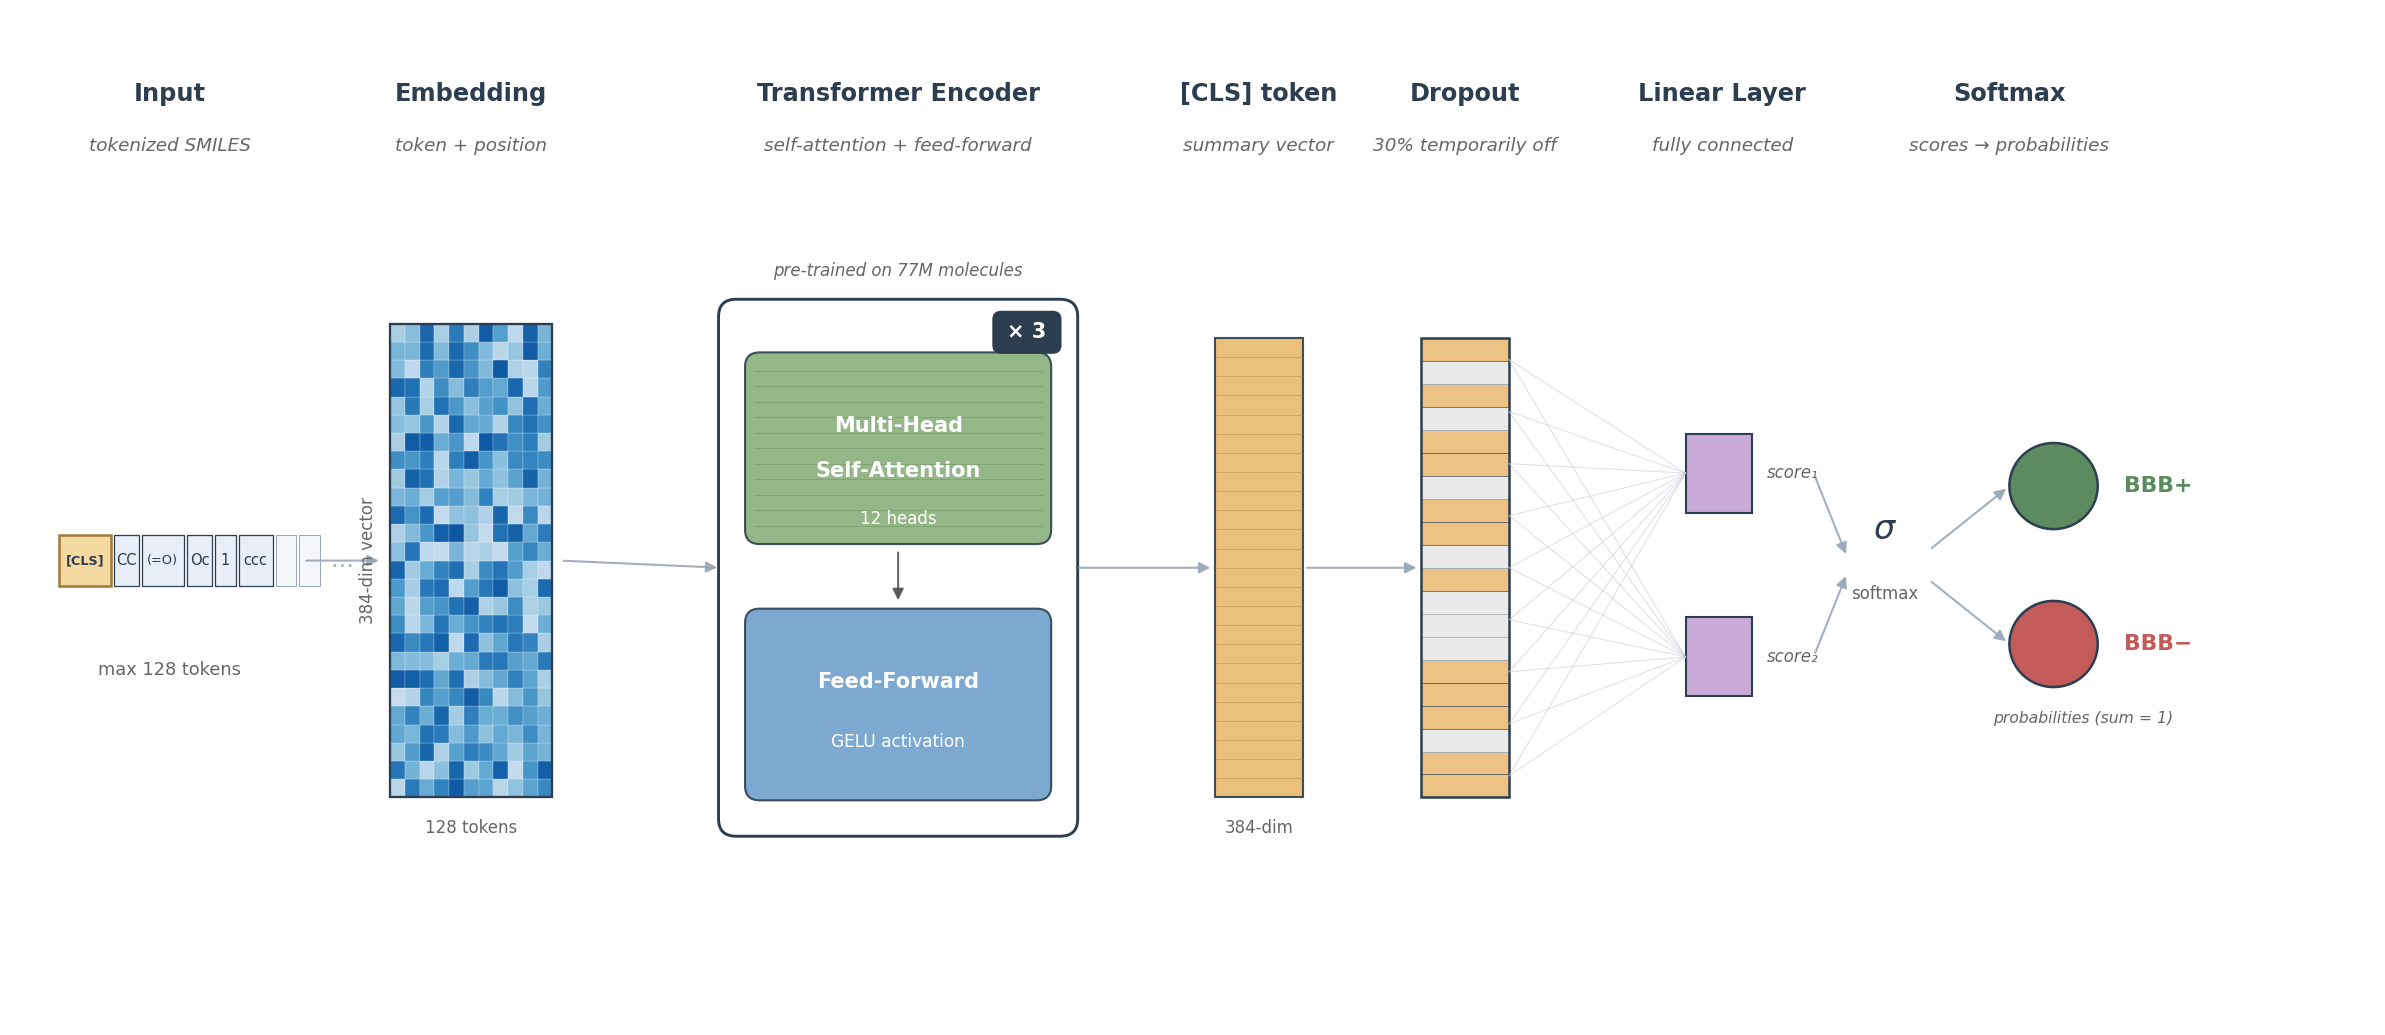

In [19]:
# === Visualization: ChemBERTa-77M-MTR architecture ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch, Circle
import numpy as np

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

COL_INPUT      = "#E8EEF7"
COL_CLS        = "#F4D9A1"; COL_CLS_DK = "#a07a3a"
COL_EMBED_CMAP = plt.cm.Blues
COL_ATTN       = "#88B07A"; COL_ATTN_DK = "#5a7a4c"
COL_FFN        = "#6FA0CC"
COL_POOL       = "#E9B96E"
COL_LOGIT      = "#C9A9D8"
COL_OUT_POS    = "#5B8B5E"; COL_OUT_NEG = "#C45B5B"
EDGE           = "#2c3e50"; EDGE_LIGHT  = "#9aa8b8"
TEXT_DIM       = "#666"

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)
ax.set_xlim(0, 16); ax.set_ylim(0, 7); ax.axis("off")

def arrow(x1, y1, x2, y2, color=EDGE_LIGHT, lw=1.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=11, linewidth=lw, color=color, alpha=0.9))

title_y, sub_y = 6.4, 6.05

# 1. Input: tokenized SMILES
ax.text(1.05, title_y, "Input", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(1.05, sub_y, "tokenized SMILES", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
tokens = ['[CLS]', 'CC', '(=O)', 'Oc', '1', 'ccc']
token_widths = [max(0.14, 0.06 * len(t) + 0.05) for t in tokens]
start_x, in_cy, cell_h, gap = 0.30, 3.2, 0.36, 0.02
x = start_x
for tok, w in zip(tokens, token_widths):
    is_cls = (tok == '[CLS]')
    color = COL_CLS if is_cls else COL_INPUT
    ec = COL_CLS_DK if is_cls else EDGE
    lw = 1.2 if is_cls else 0.6
    ax.add_patch(Rectangle((x, in_cy - cell_h/2), w, cell_h, facecolor=color, edgecolor=ec, linewidth=lw))
    fs = 6.2 if len(tok) > 3 else 7
    ax.text(x + w/2, in_cy, tok, ha="center", va="center", fontsize=fs, color=EDGE,
            fontweight="bold" if is_cls else "normal")
    x += w + gap
for _ in range(2):
    ax.add_patch(Rectangle((x, in_cy - cell_h/2), 0.14, cell_h, facecolor="#F4F6FA",
                           edgecolor=EDGE_LIGHT, linewidth=0.5))
    x += 0.14 + gap
ax.text(x + 0.05, in_cy, "…", ha="left", va="center", fontsize=11, color="#aaa")
ax.text(1.05, 2.4, "max 128 tokens", ha="center", fontsize=8.5, color=TEXT_DIM)

# 2. Embedding
ax.text(3.1, title_y, "Embedding", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(3.1, sub_y, "token + position", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
emb_x, emb_y, emb_w, emb_h = 2.55, 1.55, 1.1, 3.3
n_cols, n_rows = 11, 26
cs_w, cs_h = emb_w/n_cols, emb_h/n_rows
np.random.seed(7)
intens = 0.25 + 0.6*np.random.rand(n_rows, n_cols)
for r in range(n_rows):
    for c in range(n_cols):
        ax.add_patch(Rectangle((emb_x + c*cs_w, emb_y + r*cs_h), cs_w, cs_h,
                               facecolor=COL_EMBED_CMAP(intens[r, c]), edgecolor="white", linewidth=0.1))
ax.add_patch(Rectangle((emb_x, emb_y), emb_w, emb_h, facecolor="none", edgecolor=EDGE, linewidth=1.1))
ax.text(emb_x + emb_w/2, emb_y - 0.25, "128 tokens", ha="center", fontsize=8, color=TEXT_DIM)
ax.text(emb_x - 0.15, emb_y + emb_h/2, "384-dim vector",
        ha="center", va="center", fontsize=8, color=TEXT_DIM, rotation=90)
arrow(1.95, in_cy, 2.5, in_cy)

# 3. Transformer Encoder (× 3)
ax.text(6.0, title_y, "Transformer Encoder", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(6.0, sub_y, "self-attention + feed-forward",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
enc_x, enc_y, enc_w, enc_h = 4.8, 1.3, 2.4, 3.7
ax.add_patch(FancyBboxPatch((enc_x, enc_y), enc_w, enc_h,
    boxstyle="round,pad=0.02,rounding_size=0.12", facecolor="white", edgecolor=EDGE, linewidth=1.4))
# Attention block
attn_y, attn_h = enc_y + enc_h * 0.55, enc_h * 0.35
ax.add_patch(FancyBboxPatch((enc_x + 0.18, attn_y), enc_w - 0.36, attn_h,
    boxstyle="round,pad=0.02,rounding_size=0.10", facecolor=COL_ATTN, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
for s in range(1, 12):
    ys = attn_y + s * attn_h / 12
    ax.plot([enc_x + 0.22, enc_x + enc_w - 0.22], [ys, ys], color=COL_ATTN_DK, linewidth=0.3, alpha=0.5)
ax.text(enc_x + enc_w/2, attn_y + attn_h * 0.62, "Multi-Head",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, attn_y + attn_h * 0.38, "Self-Attention",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, attn_y + attn_h * 0.12, "12 heads",
        ha="center", va="center", fontsize=8, color="white")
# FFN block
ffn_y, ffn_h = enc_y + 0.25, enc_h * 0.35
ax.add_patch(FancyBboxPatch((enc_x + 0.18, ffn_y), enc_w - 0.36, ffn_h,
    boxstyle="round,pad=0.02,rounding_size=0.10", facecolor=COL_FFN, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
ax.text(enc_x + enc_w/2, ffn_y + ffn_h * 0.62, "Feed-Forward",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, ffn_y + ffn_h * 0.30, "GELU activation",
        ha="center", va="center", fontsize=8.2, color="white")
arrow(enc_x + enc_w/2, attn_y - 0.05, enc_x + enc_w/2, ffn_y + ffn_h + 0.05, color="#555", lw=1.0)
# × 3 badge
badge_x, badge_y = enc_x + enc_w - 0.55, enc_y + enc_h - 0.35
ax.add_patch(FancyBboxPatch((badge_x, badge_y), 0.45, 0.28,
    boxstyle="round,pad=0.01,rounding_size=0.06", facecolor=EDGE, edgecolor="none"))
ax.text(badge_x + 0.225, badge_y + 0.14, "× 3", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, enc_y + enc_h + 0.18, "pre-trained on 77M molecules",
        ha="center", fontsize=8, color=TEXT_DIM, style="italic")
arrow(3.7, in_cy, enc_x, enc_y + enc_h/2)

# 4. [CLS] token
ax.text(8.45, title_y, "[CLS] token", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(8.45, sub_y, "summary vector", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
cls_x, cls_w, cls_h = 8.15, 0.6, 3.2
cls_y = (enc_y + enc_h/2) - cls_h/2
ax.add_patch(Rectangle((cls_x, cls_y), cls_w, cls_h,
                       facecolor=COL_POOL, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
for s in range(1, 24):
    ys = cls_y + s * cls_h / 24
    ax.plot([cls_x, cls_x + cls_w], [ys, ys], color=COL_CLS_DK, linewidth=0.3, alpha=0.55)
ax.text(cls_x + cls_w/2, cls_y - 0.25, "384-dim", ha="center", fontsize=8, color=TEXT_DIM)
arrow(enc_x + enc_w, enc_y + enc_h/2, cls_x, cls_y + cls_h/2)

# 5. Dropout
ax.text(9.85, title_y, "Dropout", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(9.85, sub_y, "30% temporarily off", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
drop_x, drop_w = 9.55, 0.6
drop_h, drop_y = cls_h, cls_y
n_dots = 20
dot_h = drop_h / n_dots
np.random.seed(3)
off = np.random.rand(n_dots) < 0.30
for i in range(n_dots):
    sy = drop_y + i*dot_h
    color = "#EAEAEA" if off[i] else COL_POOL
    edge_c = EDGE_LIGHT if off[i] else EDGE
    alpha = 1.0 if off[i] else 0.85
    ax.add_patch(Rectangle((drop_x, sy), drop_w, dot_h, facecolor=color,
                           edgecolor=edge_c, linewidth=0.3, alpha=alpha))
ax.add_patch(Rectangle((drop_x, drop_y), drop_w, drop_h, facecolor="none", edgecolor=EDGE, linewidth=1.2))
arrow(cls_x + cls_w, cls_y + cls_h/2, drop_x, drop_y + drop_h/2)

# 6. Linear Layer
ax.text(11.6, title_y, "Linear Layer", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(11.6, sub_y, "fully connected", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
logit_x, logit_w, logit_h = 11.35, 0.45, 0.55
logit_y_t = drop_y + drop_h * 0.62
logit_y_b = drop_y + drop_h * 0.22
for ly in [logit_y_t, logit_y_b]:
    ax.add_patch(Rectangle((logit_x, ly), logit_w, logit_h,
                           facecolor=COL_LOGIT, edgecolor=EDGE, linewidth=1.0))
ax.text(logit_x + logit_w + 0.1, logit_y_t + logit_h/2, "score₁",
        va="center", fontsize=8, color=TEXT_DIM, style="italic")
ax.text(logit_x + logit_w + 0.1, logit_y_b + logit_h/2, "score₂",
        va="center", fontsize=8, color=TEXT_DIM, style="italic")
sample_ys = np.linspace(drop_y + 0.15, drop_y + drop_h - 0.15, 9)
for ly in sample_ys:
    for oy in [logit_y_t + logit_h/2, logit_y_b + logit_h/2]:
        ax.plot([drop_x + drop_w, logit_x], [ly, oy], color="#c0c8d4", linewidth=0.5, alpha=0.55, zorder=1)

# 7. Softmax + output
ax.text(13.55, title_y, "Softmax", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(13.55, sub_y, "scores → probabilities", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
sm_x, sm_w = 12.45, 0.5
sm_y_center = (logit_y_t + logit_y_b + logit_h) / 2
ax.text(sm_x + sm_w/2, sm_y_center + 0.25, "σ", ha="center", va="center",
        fontsize=16, color=EDGE, style="italic")
ax.text(sm_x + sm_w/2, sm_y_center - 0.2, "softmax", ha="center", va="center",
        fontsize=8, color=TEXT_DIM)
arrow(logit_x + logit_w + 0.42, logit_y_t + logit_h/2, sm_x, sm_y_center + 0.05)
arrow(logit_x + logit_w + 0.42, logit_y_b + logit_h/2, sm_x, sm_y_center - 0.05)

out_x, out_r = 13.85, 0.3
out_y_t = sm_y_center + 0.55
out_y_b = sm_y_center - 0.55
ax.add_patch(Circle((out_x, out_y_t), out_r, facecolor=COL_OUT_POS, edgecolor=EDGE, linewidth=1.2, zorder=3))
ax.add_patch(Circle((out_x, out_y_b), out_r, facecolor=COL_OUT_NEG, edgecolor=EDGE, linewidth=1.2, zorder=3))
arrow(sm_x + sm_w + 0.05, sm_y_center + 0.1, out_x - out_r, out_y_t)
arrow(sm_x + sm_w + 0.05, sm_y_center - 0.1, out_x - out_r, out_y_b)
ax.text(out_x + out_r + 0.18, out_y_t, "BBB+", va="center", fontsize=10.5, fontweight="bold", color=COL_OUT_POS)
ax.text(out_x + out_r + 0.18, out_y_b, "BBB−", va="center", fontsize=10.5, fontweight="bold", color=COL_OUT_NEG)
ax.text(out_x + 0.2, out_y_b - 0.55, "probabilities (sum = 1)",
        ha="center", fontsize=7.5, color=TEXT_DIM, style="italic")

plt.tight_layout()
plt.savefig("chemberta_architecture.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()